In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv('bottle.csv')


columns_of_interest = ['Depthm', 'T_degC', 'Salnty', 'O2ml_L', 'R_TEMP', 'R_SALINITY']
df_cleaned = df[columns_of_interest]

df_cleaned = df_cleaned.dropna(how='all')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [2]:

print("--- Central Tendency Summary ---")
ocean_mean = df_cleaned.mean()
ocean_median = df_cleaned.median()

print("Mean Values:\n", ocean_mean)
print("\nMedian Values:\n", ocean_median)


df_cleaned['T_degC'] = df_cleaned['T_degC'].fillna(ocean_mean['T_degC'])

df_cleaned['Salnty'] = df_cleaned['Salnty'].fillna(ocean_median['Salnty'])
df_cleaned['O2ml_L'] = df_cleaned['O2ml_L'].fillna(df_cleaned['O2ml_L'].median())
df_cleaned['Depthm'] = df_cleaned['Depthm'].fillna(df_cleaned['Depthm'].median())
print("\nRemaining Missing Values:\n", df_cleaned.isnull().sum())

--- Central Tendency Summary ---
Mean Values:
 Depthm        315.051162
T_degC          9.589760
Salnty         33.873884
O2ml_L          2.900162
R_TEMP          9.589790
R_SALINITY     33.873648
dtype: float64

Median Values:
 Depthm        155.00
T_degC          8.96
Salnty         33.96
O2ml_L          2.57
R_TEMP          8.96
R_SALINITY     33.96
dtype: float64

Remaining Missing Values:
 Depthm            0
T_degC            0
Salnty            0
O2ml_L            0
R_TEMP         4615
R_SALINITY    32981
dtype: int64


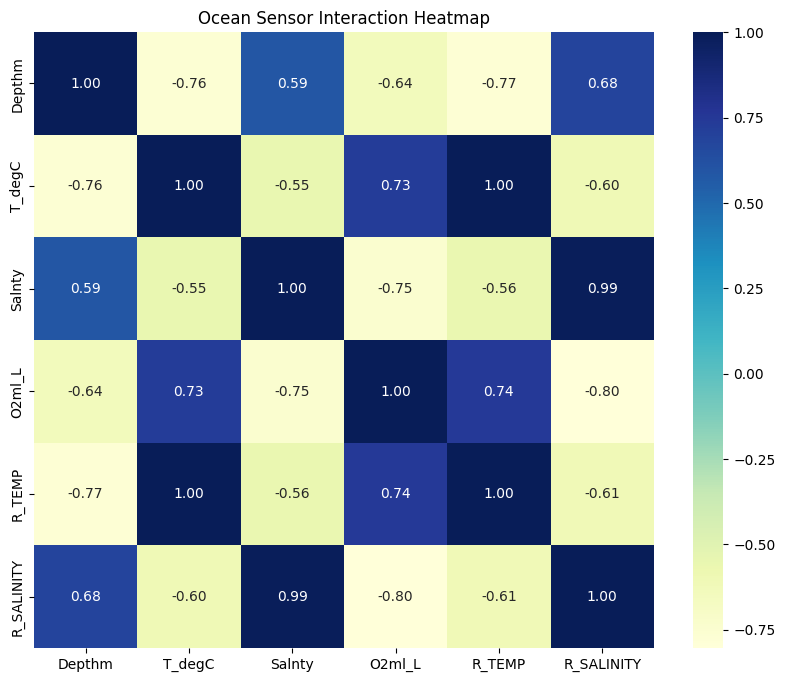

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

correlation_data = df_cleaned.corr()

sns.heatmap(correlation_data,
            annot=True,
            cmap='YlGnBu',
            fmt=".2f")

plt.title("Ocean Sensor Interaction Heatmap")
plt.show()

In [4]:
df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Date,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,1949-03,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,1949-03,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,...,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,1949-03,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,...,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,1949-03,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,...,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,1949-03,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,...,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_cleaned.describe()

,Depthm,T_degC,Salnty,O2ml_L,R_TEMP,R_SALINITY
count,162796.000000,162796.000000,162796.000000,162796.000000,158181.000000,129815.000000
mean,315.051162,9.589760,33.891330,2.843818,9.589790,33.873648
std,363.257262,4.280504,0.449283,1.964152,4.342482,0.508178
min,0.000000,1.540000,30.250000,0.000000,1.540000,4.570000
25%,50.000000,6.200000,33.586000,0.830000,6.100000,33.483000
50%,155.000000,9.100000,33.960000,2.570000,8.960000,33.960000
75%,495.000000,12.360000,34.230000,4.860000,12.530000,34.313000
max,3762.000000,28.540000,35.280000,8.710000,28.540000,35.280000


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X = df_cleaned[['Depthm', 'Salnty']]


y_temp = df_cleaned['T_degC']
y_o2 = df_cleaned['O2ml_L']

X_train, X_test, y_temp_train, y_temp_test = train_test_split(
    X, y_temp, test_size=0.2, random_state=42
)

_, _, y_o2_train, y_o2_test = train_test_split(
    X, y_o2, test_size=0.2, random_state=42
)

In [7]:
temp_model = LinearRegression()
temp_model.fit(X_train, y_temp_train)

temp_pred = temp_model.predict(X_test)

print("Temperature Prediction")
print("MSE:", mean_squared_error(y_temp_test, temp_pred))
print("R2 Score:", r2_score(y_temp_test, temp_pred))

Temperature Prediction
MSE: 7.199517220434432
R2 Score: 0.6037754983327244


In [8]:
o2_model = LinearRegression()
o2_model.fit(X_train, y_o2_train)

o2_pred = o2_model.predict(X_test)

print("\nOxygen Prediction")
print("MSE:", mean_squared_error(y_o2_test, o2_pred))
print("R2 Score:", r2_score(y_o2_test, o2_pred))


Oxygen Prediction
MSE: 1.464310701476658
R2 Score: 0.6216853378997


In [9]:
df_cleaned['SafeRoute'] = (
    (df_cleaned['T_degC'] >= 2) &
    (df_cleaned['T_degC'] <= 30) &
    (df_cleaned['Salnty'] >= 30) &
    (df_cleaned['Salnty'] <= 38) &
    (df_cleaned['O2ml_L'] > 2) &
    (df_cleaned['Depthm'] > 50)
).astype(int)

In [10]:
df_cleaned['WaterCondition'] = np.where(
    (df_cleaned['T_degC'] > 25) & (df_cleaned['O2ml_L'] < 3),
    "Poor",
    np.where(df_cleaned['O2ml_L'] < 2, "Danger", "Normal")
)
df_cleaned['DensityIndex'] = df_cleaned['Salnty'] - df_cleaned['T_degC']*0.2
df_cleaned['VisibilityRisk'] = np.where(
    (df_cleaned['O2ml_L'] < 2.5) | (df_cleaned['T_degC'] > 28),
    "Low Visibility Risk",
    "Normal"
)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_ml = df_cleaned.copy()

le = LabelEncoder()
df_ml['WaterCondition'] = le.fit_transform(df_ml['WaterCondition'])
df_ml['VisibilityRisk'] = le.fit_transform(df_ml['VisibilityRisk'])

X = df_ml[['Depthm','Salnty','DensityIndex','WaterCondition','VisibilityRisk']]
y = df_ml['SafeRoute']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8800675675675675
[[18396  2084]
 [ 1821 10259]]
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     20480
           1       0.83      0.85      0.84     12080

    accuracy                           0.88     32560
   macro avg       0.87      0.87      0.87     32560
weighted avg       0.88      0.88      0.88     32560



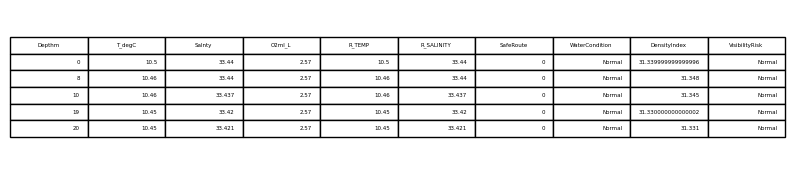

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
plt.table(cellText=df_cleaned.head().values,
          colLabels=df_cleaned.columns,
          loc='center')
plt.axis('off')
plt.savefig("cleaned_dataset.png", bbox_inches='tight')
plt.show()

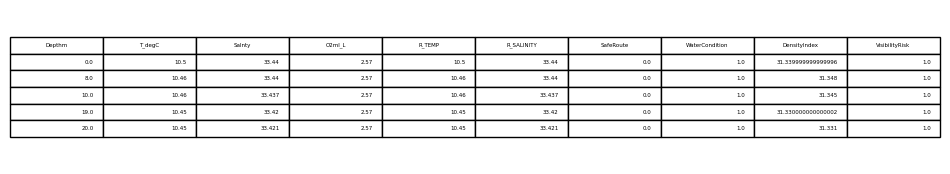

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,2))
plt.table(cellText=df_ml.head().values,
          colLabels=df_ml.columns,
          loc='center')
plt.axis('off')
plt.savefig("df_ml_sample.png", bbox_inches='tight')
plt.show()

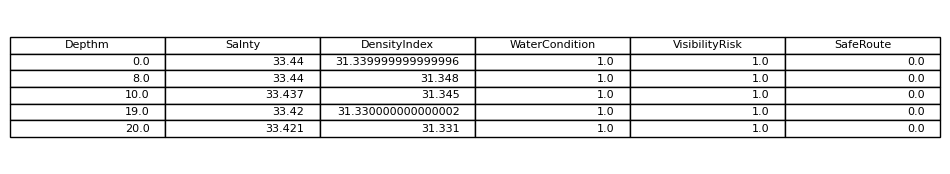

In [15]:
import matplotlib.pyplot as plt

cols = ['Depthm','Salnty','DensityIndex',
        'WaterCondition','VisibilityRisk','SafeRoute']

plt.figure(figsize=(12,2))
plt.table(cellText=df_ml[cols].head().values,
          colLabels=cols,
          loc='center')
plt.axis('off')
plt.savefig("feature_dataset.png", bbox_inches='tight')
plt.show()

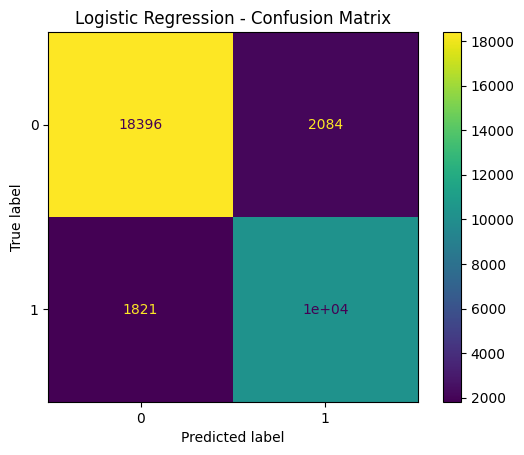

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.title("Logistic Regression - Confusion Matrix")
plt.savefig("logistic_confusion_matrix.png")
plt.show()

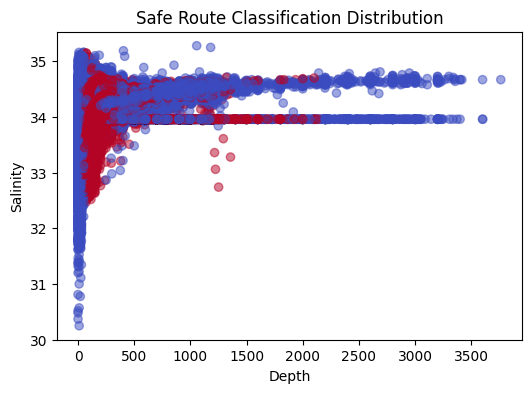

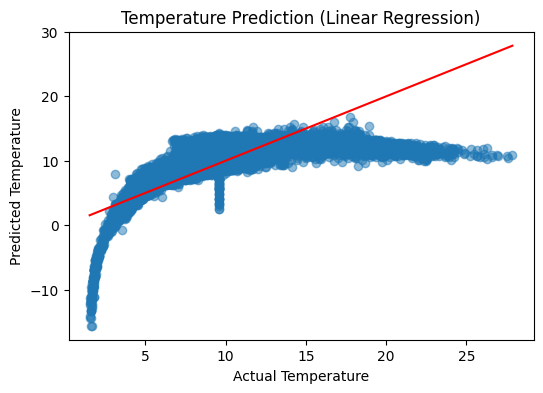

In [18]:
plt.figure(figsize=(6,4))

plt.scatter(y_temp_test, temp_pred, alpha=0.5)
plt.plot([y_temp_test.min(), y_temp_test.max()],
         [y_temp_test.min(), y_temp_test.max()],
         color='red')

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Temperature Prediction (Linear Regression)")

plt.savefig("temp_regression.png")
plt.show()

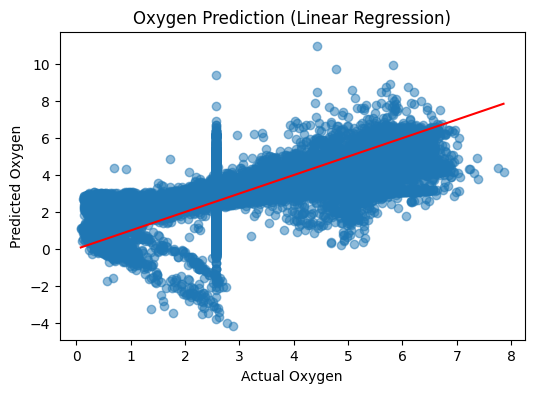

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(y_o2_test, o2_pred, alpha=0.5)
plt.plot([y_o2_test.min(), y_o2_test.max()],
         [y_o2_test.min(), y_o2_test.max()],
         color='red')

plt.xlabel("Actual Oxygen")
plt.ylabel("Predicted Oxygen")
plt.title("Oxygen Prediction (Linear Regression)")

plt.savefig("oxygen_regression.png")
plt.show()